In [215]:
# Part 2
# Problem 1
import numpy as np
import sympy as sp

l1, l2, theta1, theta2, t = sp.symbols('l1 l2 theta1 theta2 t')

theta1= sp.Function('theta1')(t)
theta2= sp.Function('theta2')(t)

print(l1, l2, theta1, theta2)

l1 l2 theta1(t) theta2(t)


In [216]:
# Part 2
# Problem 2
def Transform(x,y,theta):
    T=sp.Matrix([
        [sp.cos(theta), -sp.sin(theta), x],
        [sp.sin(theta),  sp.cos(theta), y],
        [0,               0,              1                 ]
    ])
    return T
#Call Transform using: 
T01 = Transform(l1*sp.cos(theta1),l1*sp.sin(theta1),theta1)
T12 = Transform(l2*sp.cos(theta2),l2*sp.sin(theta2),theta2)
T02= sp.simplify(T01*T12)

In [217]:
T02

Matrix([
[cos(theta1(t) + theta2(t)), -sin(theta1(t) + theta2(t)), l1*cos(theta1(t)) + l2*cos(theta1(t) + theta2(t))],
[sin(theta1(t) + theta2(t)),  cos(theta1(t) + theta2(t)), l1*sin(theta1(t)) + l2*sin(theta1(t) + theta2(t))],
[                         0,                           0,                                                 1]])

In [218]:
# Part 2
# Problem 3
# Position of mass 1
pos1 = T01[:2, 2]  # first 2 rows, 3rd column
pose1 = sp.simplify(pos1)

# Position of mass 2
pos2 = T02[:2, 2]  # first 2 rows, 3rd column
pose2 = sp.simplify(pos2)

In [219]:
pose1

Matrix([
[l1*cos(theta1(t))],
[l1*sin(theta1(t))]])

In [220]:
pose2

Matrix([
[l1*cos(theta1(t)) + l2*cos(theta1(t) + theta2(t))],
[l1*sin(theta1(t)) + l2*sin(theta1(t) + theta2(t))]])

In [221]:
# Part 2
# Problem 4
# Body twist for mass 1
Vb1 = T01.inv() * sp.diff(T01, t)
wz1 = Vb1[1, 0]
vx1 = Vb1[0, 2]
vy1 = Vb1[1, 2]
Vb1_vec = sp.Matrix([wz1, vx1, vy1])
Vb1_vec = sp.simplify(Vb1_vec)

# Body twist for mass 2
Vb2 = T02.inv() * sp.diff(T02, t)
wz2 = Vb2[1, 0]
vx2 = Vb2[0, 2]
vy2 = Vb2[1, 2]
Vb2_vec = sp.Matrix([wz2, vx2, vy2])
Vb2_vec= sp.simplify(Vb2_vec)

In [222]:
Vb1_vec

Matrix([
[   Derivative(theta1(t), t)],
[                          0],
[l1*Derivative(theta1(t), t)]])

In [223]:
Vb2_vec

Matrix([
[                                                   Derivative(theta1(t), t) + Derivative(theta2(t), t)],
[                                                            l1*sin(theta2(t))*Derivative(theta1(t), t)],
[l1*cos(theta2(t))*Derivative(theta1(t), t) + l2*Derivative(theta1(t), t) + l2*Derivative(theta2(t), t)]])

In [224]:
# Part 2 
# Problem 4
#Finding the Jacobian
# Define theta_dot as symbols
theta1_dot = sp.diff(theta1, t)
theta2_dot = sp.diff(theta2, t)

# Stack them into a vector
q_dot = sp.Matrix([theta1_dot, theta2_dot])

# Compute Jacobian — this extracts coefficients of theta1_dot and theta2_dot
Jb1 = Vb1_vec.jacobian(q_dot)
Jb2 = Vb2_vec.jacobian(q_dot)

#To Double Check, Jb1 * q_dot=Vb1_vec
#Jb1*q_dot

In [225]:
Jb1

Matrix([
[ 1, 0],
[ 0, 0],
[l1, 0]])

In [226]:
Jb2

Matrix([
[                     1,  1],
[     l1*sin(theta2(t)),  0],
[l1*cos(theta2(t)) + l2, l2]])

In [227]:
# Part 2
# Problem 5
from scipy.optimize import minimize

# Step 1: Create a lambda function for position of mass 2
# pos2 is already defined as T02[:2, 2] — convert it to a numeric function

pos2_func = sp.lambdify([theta1, theta2, l1, l2], pos2, 'numpy')

# Step 2: Define your link lengths (actual numbers now)
L1 = 1.0
L2 = 1.0

# Step 3: Define the IK cost function
# We want to find theta1, theta2 such that pos2_func == desired (x, y)
def ik_cost(thetas, x_des, y_des):
    th1, th2 = thetas
    pos = pos2_func(th1, th2, L1, L2)
    return (pos[0] - x_des)**2 + (pos[1] - y_des)**2

# Step 4: Solve for a desired position
x_desired = 1.5
y_desired = 0.5

result = minimize(ik_cost, x0=[0.1, 0.1], args=(x_desired, y_desired))

print("Found thetas:", result.x)
print("Converged:", result.success)

# Verify by plugging back in
th1_sol, th2_sol = result.x
print("Resulting position:", pos2_func(th1_sol, th2_sol, L1, L2))

Found thetas: [-0.33730687  1.31811569]
Converged: True
Resulting position: [[1.50000001]
 [0.5000007 ]]


In [228]:
# Part 3 Problem 1a
import numpy as np
#Generate Random valued Vectors
def random_rotation():
    theta = np.random.uniform(0,2*np.pi)
    n = np.random.randn(3)
    n = n/np.linalg.norm(n)
    nx, ny, nz = n
    nskew = np.array([
        [0, -nz, ny],
        [nz, 0, -nx],
        [-ny, nx, 0]
    ])
    I = np.eye(3)
    R = I + np.sin(theta)*nskew + (1 - np.cos(theta))*(nskew @ nskew)
    return R
#To Double Check Math
#print(np.linalg.det(R))  # should be exactly 1.0
#print(R @ R.T)           # should be identity (1s on diagonal, 0s off)

In [229]:
# Part 3 Problem 1B
#Initialize
rotations=[]
for i in range(9):
    R=random_rotation()
    rotations.append(R)
    print(np.linalg.det(R))


0.9999999999999991
0.9999999999999998
0.9999999999999998
0.9999999999999999
1.0
1.0
1.0000000000000004
1.0000000000000002
1.0000000000000007


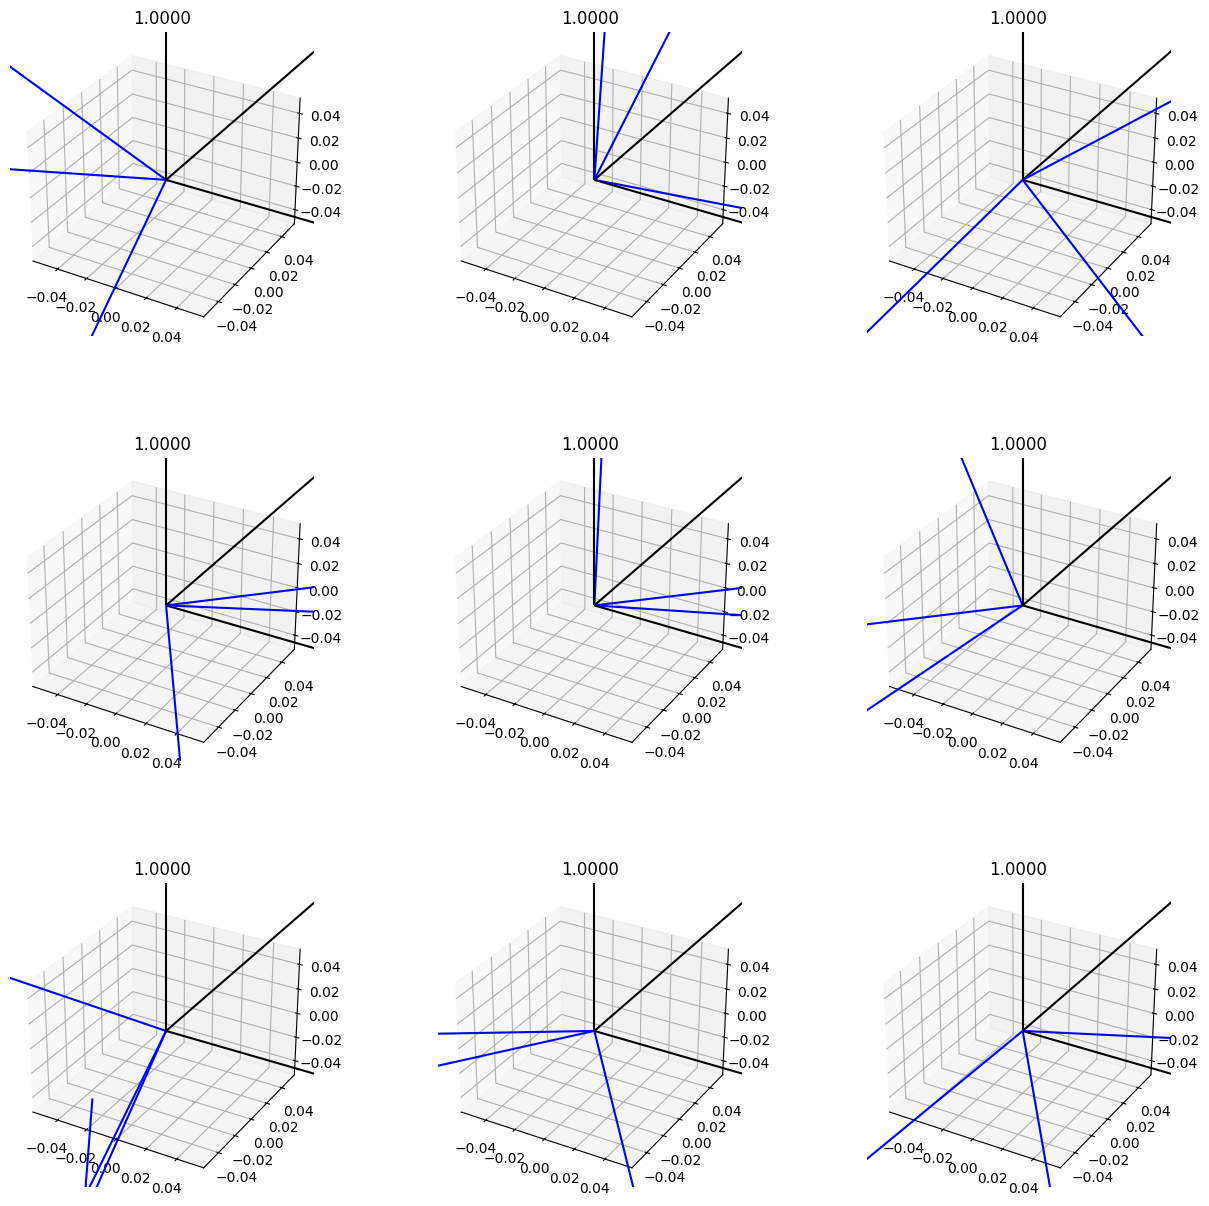

In [230]:
# Part 3 Problem 1C
import matplotlib.pyplot as plt

def frame_plot(R, ax):
    # World frame
    ax.quiver(0, 0, 0, 1, 0, 0, color='black')
    ax.quiver(0, 0, 0, 0, 1, 0, color='black')
    ax.quiver(0, 0, 0, 0, 0, 1, color='black')
    
    # Rotated frame
    ax.quiver(0, 0, 0, R[0,0], R[1,0], R[2,0], color='blue')
    ax.quiver(0, 0, 0, R[0,1], R[1,1], R[2,1], color='blue')
    ax.quiver(0, 0, 0, R[0,2], R[1,2], R[2,2], color='blue')
    ax.set_title(f"{np.linalg.det(R):.4f}")

# Create 3x3 figure with larger size and more spacing
fig, axes = plt.subplots(3, 3, subplot_kw={'projection': '3d'}, figsize=(15, 15))

for i in range(9):
    ax = axes[i//3, i%3]
    frame_plot(rotations[i], ax)

plt.subplots_adjust(wspace=0.4, hspace=0.4)
plt.show()

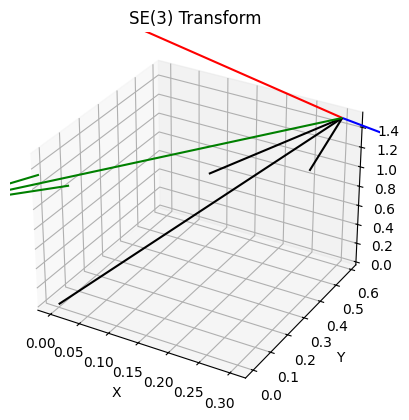

Translation vector p:
 [0.30274841 0.58757747 1.51952788]
Rotation matrix R:
 [[ 0.06700293 -0.43513737 -0.89786751]
 [ 0.43152859 -0.79873277  0.41929589]
 [-0.89960752 -0.41554956  0.13425678]]


In [231]:
# Problem 3 Part 2a
# Generate random T outside the function
R = random_rotation()
p = np.random.randn(3)
T = np.eye(4)
T[:3, :3] = R
T[:3, 3] = p

# Function just takes T and plots it
def plot_transform(T):
    # Extract R and p from T
    R = T[:3, :3]
    p = T[:3, 3]
    
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    
    # Black line from world origin to p
    ax.quiver(0, 0, 0, p[0], p[1], p[2], color='black')
    
    # Coordinate frame at p — arrows start at p instead of origin
    ax.quiver(p[0], p[1], p[2], R[0,0], R[1,0], R[2,0], color='blue')
    ax.quiver(p[0], p[1], p[2], R[0,1], R[1,1], R[2,1], color='green')
    ax.quiver(p[0], p[1], p[2], R[0,2], R[1,2], R[2,2], color='red')
    
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title('SE(3) Transform')
    
    # Print R and p below plot
    plt.show()
    print("Translation vector p:\n", p)
    print("Rotation matrix R:\n", R)
plot_transform(T)

In [232]:
# Problem 3 Part 2b
xyz= np.random.randn(3)
v=np.append(xyz,1)
v_transformed = T @ v

#The Vector Norm of xyz compared to the Transformed vector Norm - the translation p
if np.isclose(np.linalg.norm(xyz), np.linalg.norm(v_transformed[:3] - p)):
    print("Length is unchanged")
else:
    print("Error: Length Changed")

Length is unchanged
